In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [44]:
x,y = make_classification(n_samples=100, n_features=2, n_informative=1, random_state=31, n_classes=2, n_clusters_per_class=1, n_redundant=0, class_sep=0.3)

In [45]:
y

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0])

<Axes: >

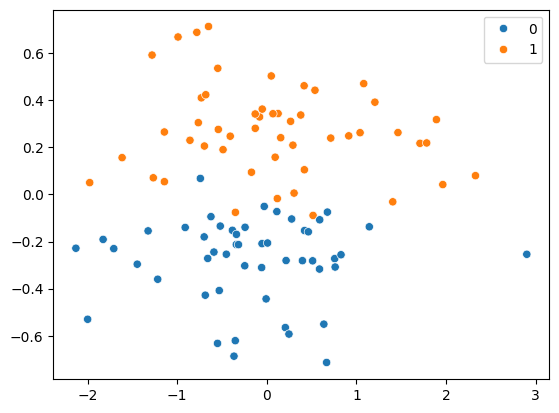

In [46]:
import seaborn as sns
sns.scatterplot(x = x[:,0], y = x[:,1], hue=y)

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [28]:
from keras.layers import Dense, Dropout, Input
from keras.models import Sequential
from keras.optimizers import Adam


In [29]:
from sklearn.metrics import mean_squared_error

In [58]:
model = Sequential([
    Input(shape=(2,)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [59]:
model.compile(optimizer='Adam',metrics=['accuracy'], loss='binary_crossentropy' )

In [60]:
history = model.fit(x_train, y_train, epochs=300, verbose=1, validation_data=(x_test, y_test))

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5625 - loss: 0.6909 - val_accuracy: 0.9000 - val_loss: 0.6677
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8875 - loss: 0.6659 - val_accuracy: 0.9500 - val_loss: 0.6412
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 0.6452 - val_accuracy: 0.9500 - val_loss: 0.6179
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8875 - loss: 0.6258 - val_accuracy: 0.9500 - val_loss: 0.5954
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9000 - loss: 0.6059 - val_accuracy: 0.9500 - val_loss: 0.5754
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8875 - loss: 0.5840 - val_accuracy: 0.9500 - val_loss: 0.5525
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8875 - loss: 0.5616 - val_accuracy: 0.9500 - val_loss: 0.5244
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8875 - loss: 0.5349 - val_accuracy: 0.9500 - val_loss

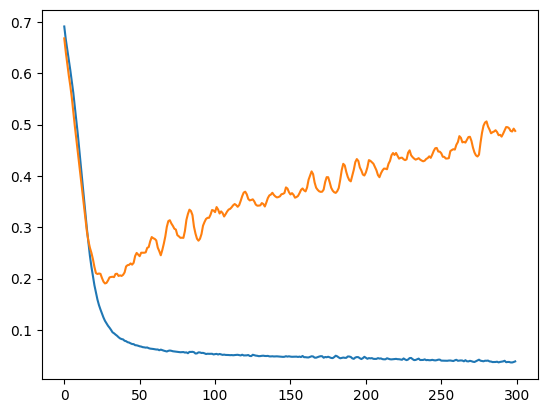

In [61]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

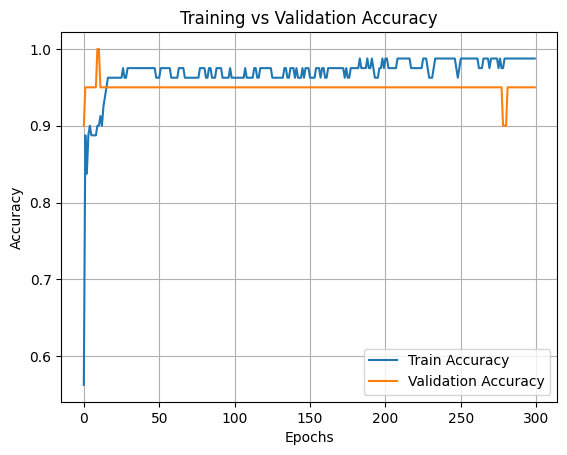

In [64]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)
plt.show()

Now incorporating the dropouts in the model

In [65]:
model = Sequential([
    Input(shape=(2,)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [66]:
model.compile(optimizer='Adam',metrics=['accuracy'], loss='binary_crossentropy' )

In [67]:
history = model.fit(x_train, y_train, epochs=300, verbose=1, validation_data=(x_test, y_test))

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4875 - loss: 0.6979 - val_accuracy: 0.9500 - val_loss: 0.6645
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7375 - loss: 0.6720 - val_accuracy: 0.9500 - val_loss: 0.6471
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7625 - loss: 0.6568 - val_accuracy: 0.9000 - val_loss: 0.6314
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7625 - loss: 0.6508 - val_accuracy: 0.9000 - val_loss: 0.6156
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8500 - loss: 0.6289 - val_accuracy: 0.9000 - val_loss: 0.6000
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8125 - loss: 0.6217 - val_accuracy: 0.9000 - val_loss: 0.5838
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9000 - loss: 0.5916 - val_accuracy: 0.9000 - val_loss: 0.5658
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.5683 - val_accuracy: 0.9000 - val_loss

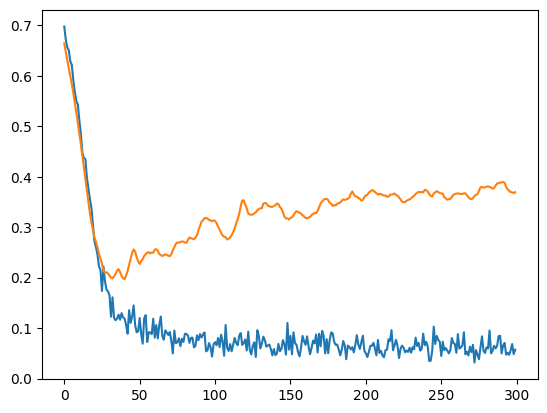

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

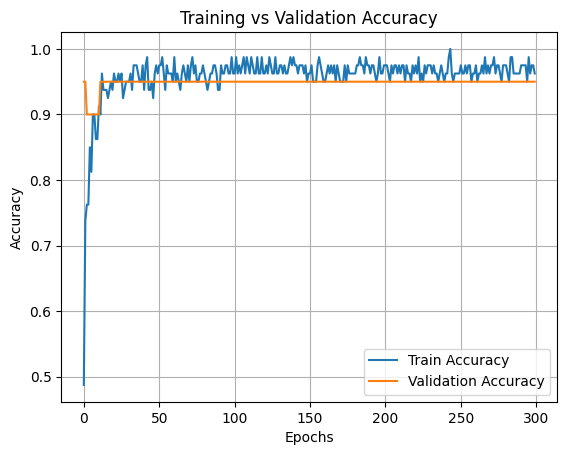

In [69]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)
plt.show()